In [1]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import cv2
import warnings
import random
warnings.filterwarnings('ignore')

In [2]:

ds1_path = "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset/Training"
ds2_path = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
ds3_path = "/kaggle/input/datasets/sabersakin/brainmri/Datasest Merged 1/Datasest Merged 1"

dataset_paths=np.array([ds1_path,ds2_path,ds3_path])

pituitary=np.array([])
no_tumor=np.array([])
meningioma=np.array([])
glioma=np.array([])

classes=np.array([pituitary,no_tumor,meningioma,glioma])

for ds in dataset_paths:
    count=-1
    for dirs in os.listdir(ds):
        paths=os.path.join(ds,dirs)
        count+=1
        for filename in os.listdir(paths):
            if count==0:
                pituitary=np.append(pituitary,os.path.join(paths,filename))
            elif count==1:
                no_tumor=np.append(no_tumor,os.path.join(paths,filename))
            elif count==2:
                meningioma=np.append(meningioma,os.path.join(paths,filename))
            elif count==3:
                glioma=np.append(glioma,os.path.join(paths,filename))

In [3]:
print(" Glioma:",len(glioma), "\n",
      "Meningioma:",len(meningioma), "\n",
      "Pituitary:",len(pituitary), "\n",
      "No-Tumor:",len(no_tumor), "\n",
     )

 Glioma: 6694 
 Meningioma: 6029 
 Pituitary: 6445 
 No-Tumor: 5495 



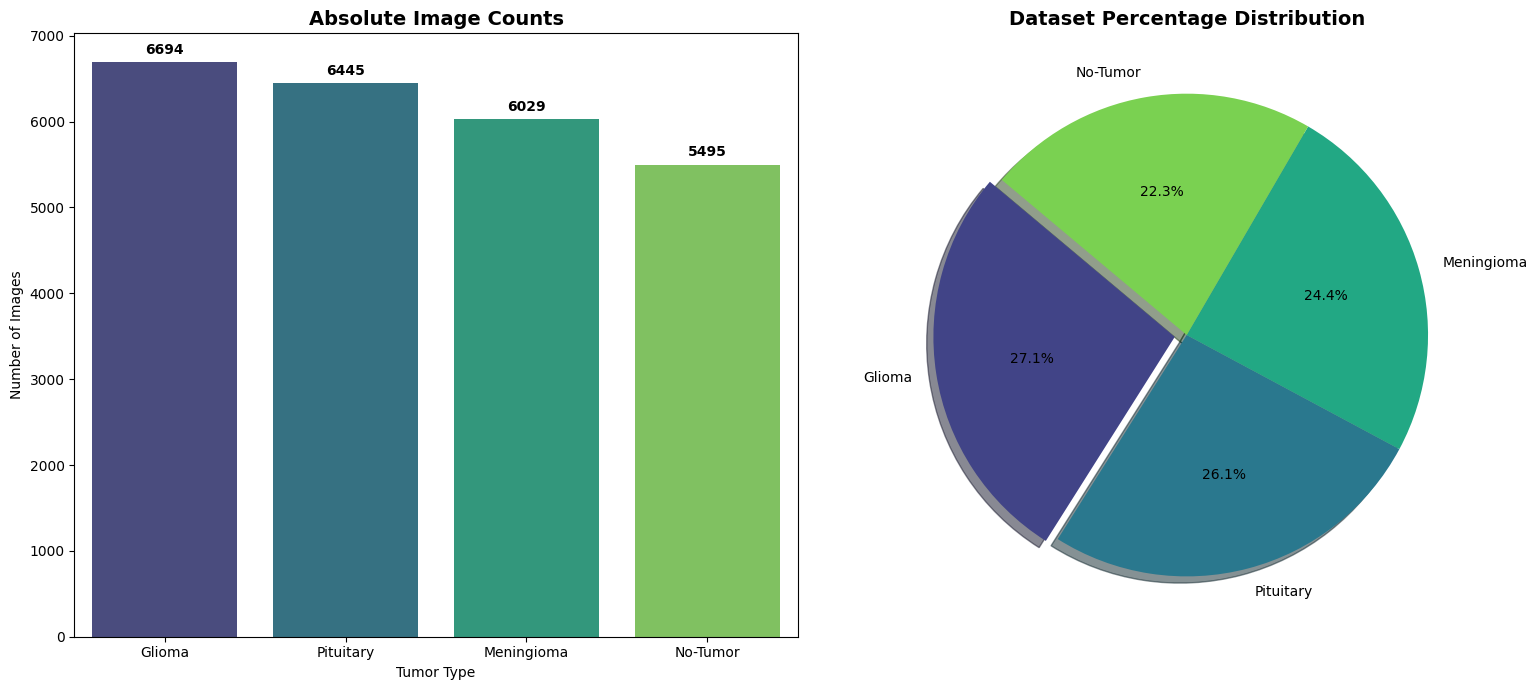

In [4]:

data = {
    'Tumor Type': ['Glioma', 'Pituitary', 'Meningioma', 'No-Tumor'],
    'Count': [len(glioma), len(pituitary), len(meningioma), len(no_tumor)]
}
df = pd.DataFrame(data).sort_values(by='Count', ascending=False)

# 2. Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))


sns.barplot(x='Tumor Type', y='Count', data=df, palette='viridis', ax=ax1)
ax1.set_title('Absolute Image Counts', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Images')


for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold')


colors = sns.color_palette('viridis', len(df))
ax2.pie(df['Count'], labels=df['Tumor Type'], autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=[0.05, 0, 0, 0], shadow=True)
ax2.set_title('Dataset Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

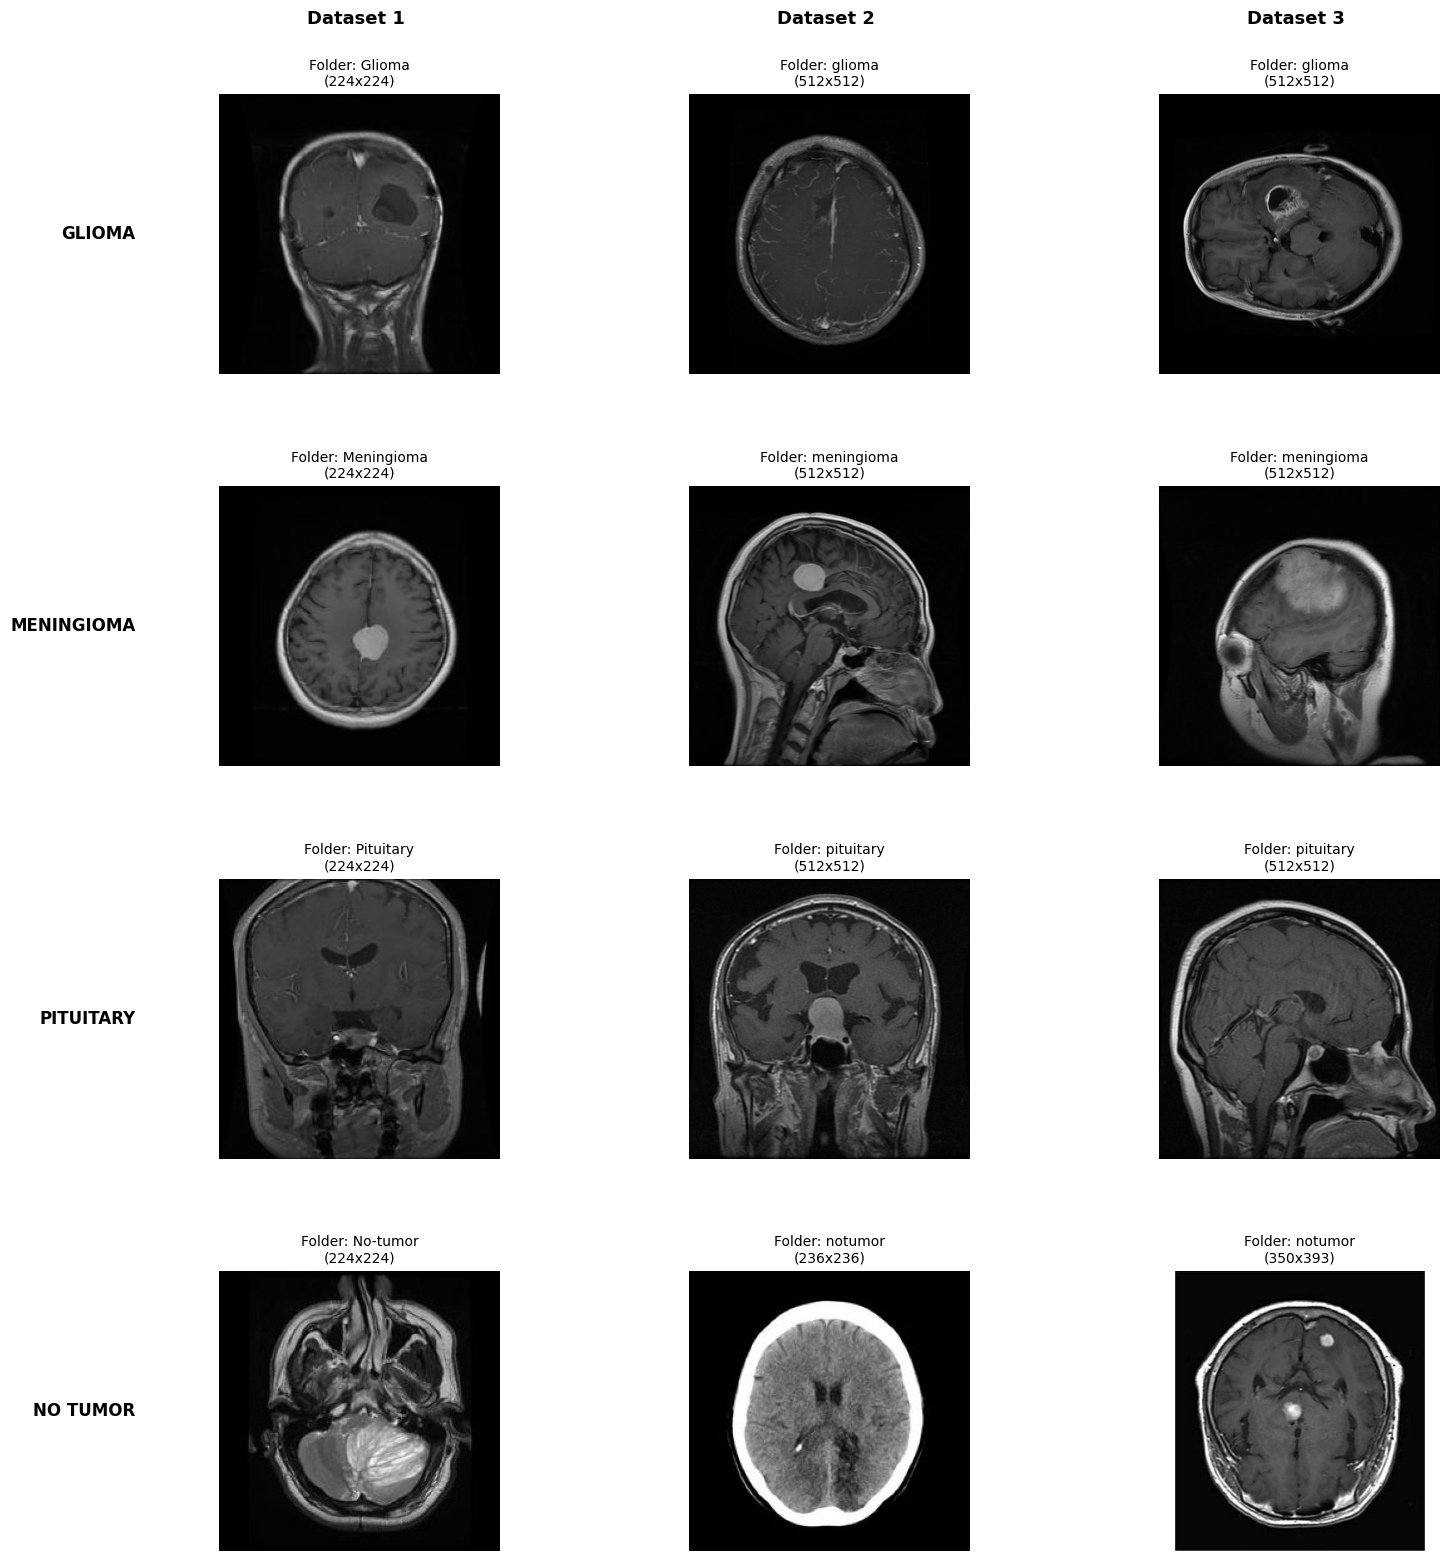

In [5]:
dataset_paths = [ds1_path, ds2_path, ds3_path]
dataset_names = ["Dataset 1 ", "Dataset 2 ", "Dataset 3 "]


standard_classes = ["glioma", "meningioma", "pituitary", "no_tumor"]


fig, axes = plt.subplots(len(standard_classes), len(dataset_paths), figsize=(15, 16))


def find_matching_folder(base_path, target_cls):
    if not os.path.exists(base_path):
        return None
    for folder in os.listdir(base_path):
        if os.path.isdir(os.path.join(base_path, folder)):
           
            clean_folder = folder.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            clean_target = target_cls.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            if clean_target in clean_folder or clean_folder in clean_target:
                return folder
    return None


for col_idx, path in enumerate(dataset_paths):
    for row_idx, std_cls in enumerate(standard_classes):
        ax = axes[row_idx, col_idx]
        

        matched_folder = find_matching_folder(path, std_cls)
        
        if matched_folder:
            cls_folder = os.path.join(path, matched_folder)
            images = [f for f in os.listdir(cls_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if images:
                random_img = random.choice(images)
                img_path = os.path.join(cls_folder, random_img)
                
                
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    ax.imshow(img)
                    # Label with the folder name found in that specific dataset + dimensions
                    ax.set_title(f"Folder: {matched_folder}\n({img.shape[1]}x{img.shape[0]})", fontsize=10)
                else:
                    ax.text(0.5, 0.5, "Read Error", ha='center', va='center', color='red')
            else:
                ax.text(0.5, 0.5, "No Images Found", ha='center', va='center', color='orange')
        else:
            ax.text(0.5, 0.5, f"Class Not Found\n({std_cls})", ha='center', va='center', color='red')
            
        ax.axis('off')


for col_idx, name in enumerate(dataset_names):
    axes[0, col_idx].text(0.5, 1.25, name, fontsize=13, fontweight='bold', 
                          ha='center', transform=axes[0, col_idx].transAxes)

# Add Row Labels on the far left side
for row_idx, std_cls in enumerate(standard_classes):
    axes[row_idx, 0].text(-0.3, 0.5, std_cls.upper().replace("_", " "), fontsize=12, fontweight='bold',
                          va='center', ha='right', transform=axes[row_idx, 0].transAxes, rotation=0)

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
plt.show()

This is a new line.

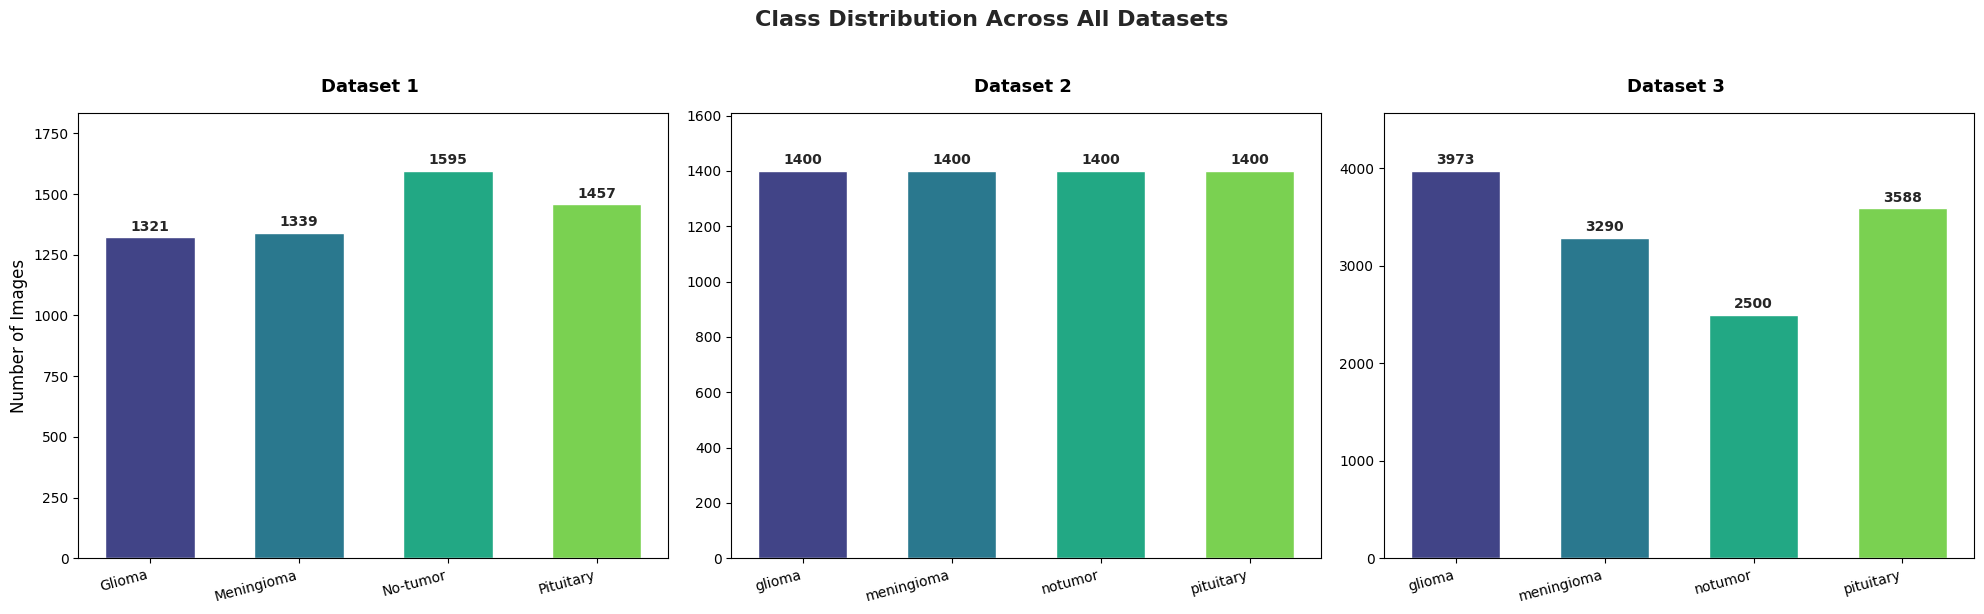

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
sns.set_theme(style="whitegrid")


for idx, path in enumerate(dataset_paths):
    class_counts = {}
    
    
    if os.path.exists(path):
        classes = sorted(os.listdir(path))
        for cls in classes:
            cls_folder = os.path.join(path, cls)
            if os.path.isdir(cls_folder):
                count = len([f for f in os.listdir(cls_folder) if not f.startswith('.')])
                class_counts[cls] = count
    else:
        print(f"Warning: Path not found for {dataset_names[idx]}")
        continue

   
    ax = axes[idx]
    if class_counts:
        colors = sns.color_palette("viridis", len(class_counts))
        bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, width=0.6)
        
      
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2.0, yval + (max(class_counts.values()) * 0.01), 
                    f'{yval}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
       
        ax.set_title(dataset_names[idx], fontsize=13, fontweight='bold', pad=15)
        ax.set_xticklabels(class_counts.keys(), rotation=15, ha='right', fontsize=10)
        ax.set_ylim(0, max(class_counts.values()) * 1.15) 
        if idx == 0:
            ax.set_ylabel("Number of Images", fontsize=12)
    else:
        ax.text(0.5, 0.5, "No Data Found", ha='center', va='center', fontsize=14)


plt.suptitle("Class Distribution Across All Datasets", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

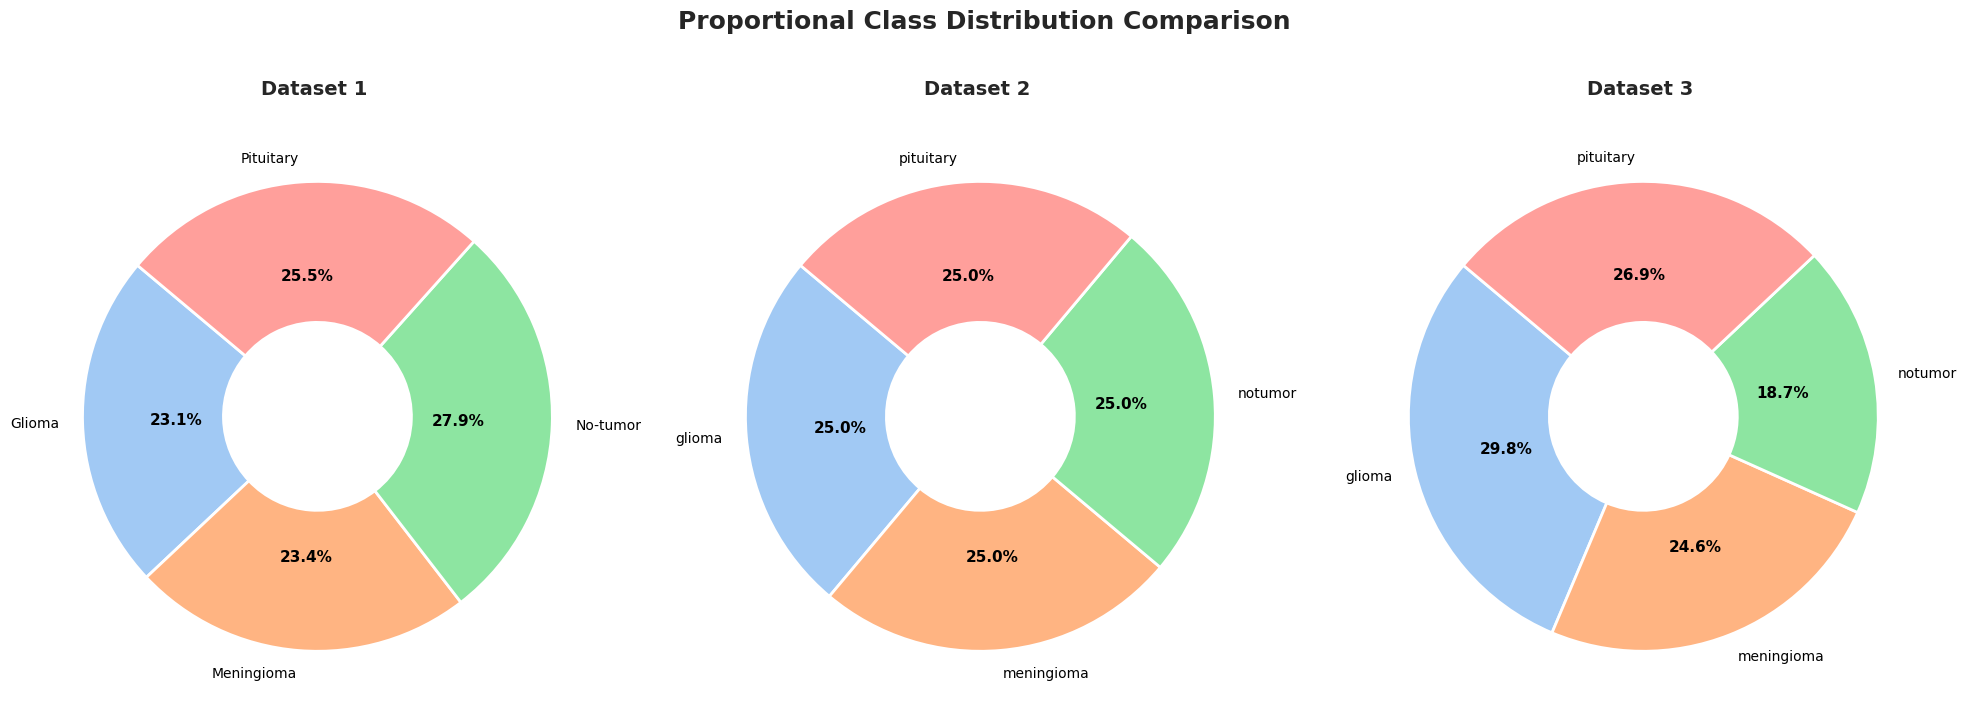

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.set_theme(style="white")


colors = sns.color_palette("pastel", 4)

for idx, path in enumerate(dataset_paths):
    class_counts = {}
    
    if os.path.exists(path):
        
        classes = sorted([c for c in os.listdir(path) if os.path.isdir(os.path.join(path, c))])
        for cls in classes:
            cls_folder = os.path.join(path, cls)
            count = len([f for f in os.listdir(cls_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            if count > 0:
                class_counts[cls] = count
    
    ax = axes[idx]
    
    if class_counts:
        labels = list(class_counts.keys())
        sizes = list(class_counts.values())
        
        # Plot the pie chart
        wedges, texts, autotexts = ax.pie(
            sizes, 
            labels=labels, 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=colors[:len(labels)],
            textprops=dict(color="black", fontsize=10),
            wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2) # Creates a clean donut-style look
        )
        
      
        for autotext in autotexts:
            autotext.set_fontsize(11)
            autotext.set_weight('bold')
            
        ax.set_title(dataset_names[idx], fontsize=14, fontweight='bold', pad=20)
    else:
        ax.text(0.5, 0.5, f"Data path missing\nor empty", ha='center', va='center', fontsize=12, color='red')
        ax.axis('off')


plt.suptitle("Proportional Class Distribution Comparison", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

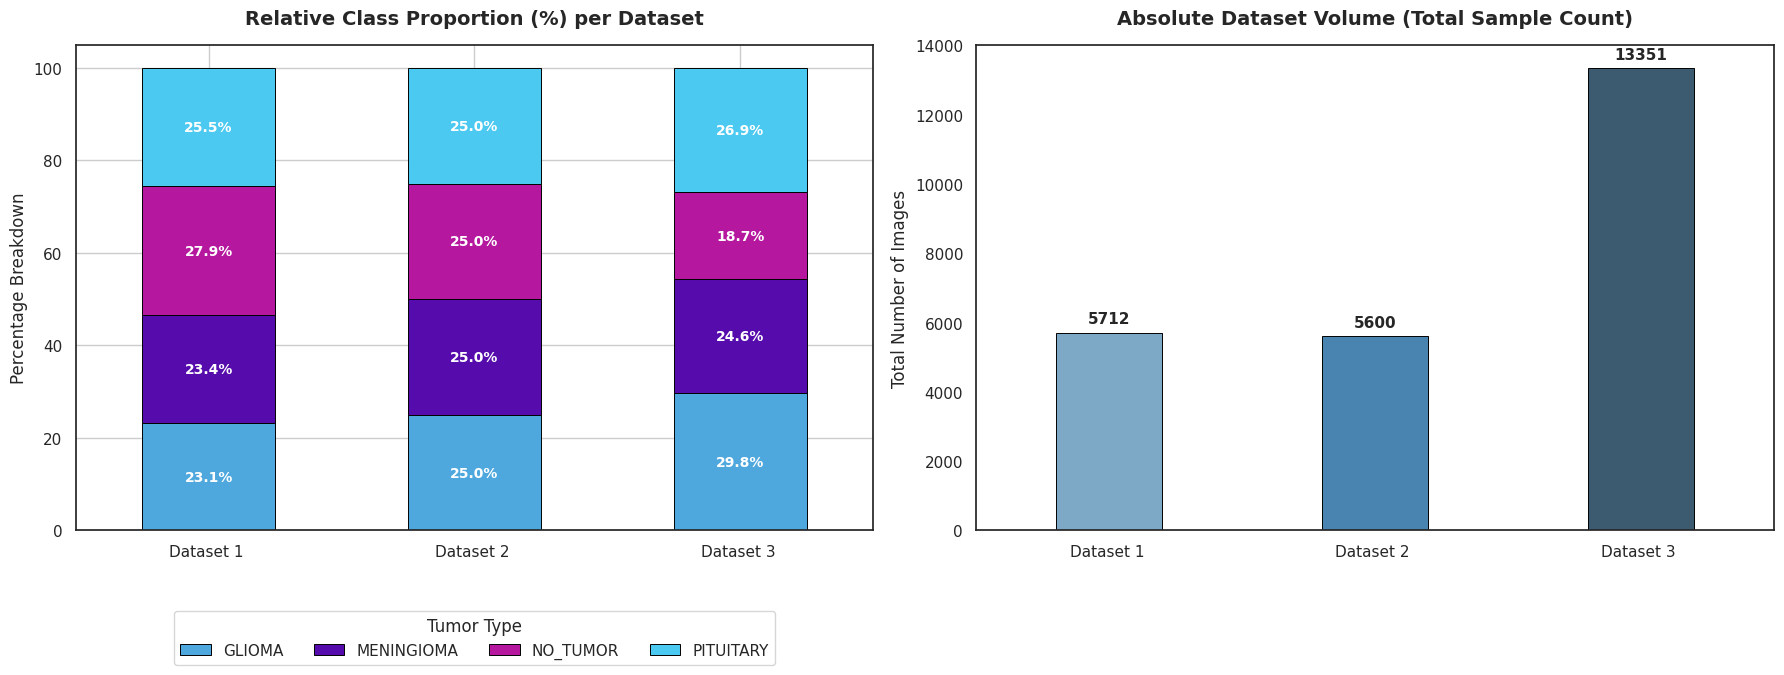

In [8]:

standard_classes = ["glioma", "meningioma", "pituitary", "no_tumor"]

def find_matching_folder(base_path, target_cls):
    if not os.path.exists(base_path): return None
    for folder in os.listdir(base_path):
        if os.path.isdir(os.path.join(base_path, folder)):
            clean_folder = folder.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            clean_target = target_cls.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            if clean_target in clean_folder or clean_folder in clean_target:
                return folder
    return None


data_records = []
for name, path in zip(dataset_names, dataset_paths):
    for std_cls in standard_classes:
        matched_folder = find_matching_folder(path, std_cls)
        if matched_folder:
            cls_folder = os.path.join(path, matched_folder)
            count = len([f for f in os.listdir(cls_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            data_records.append({"Dataset": name, "Class": std_cls.upper(), "Count": count})
        else:
            data_records.append({"Dataset": name, "Class": std_cls.upper(), "Count": 0})

df = pd.pivot_table(pd.DataFrame(data_records), values='Count', index='Dataset', columns='Class', aggfunc='sum')
df_percent = df.div(df.sum(axis=1), axis=0) * 100


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")
colors = ["#4ea8de", "#560bad", "#b5179e", "#4cc9f0"]


df_percent.plot(kind='bar', stacked=True, color=colors, ax=ax1, width=0.5, edgecolor='black', linewidth=0.7)
ax1.set_title("Relative Class Proportion (%) per Dataset", fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel("Percentage Breakdown", fontsize=12)
ax1.set_xlabel("")
ax1.set_xticklabels(df_percent.index, rotation=0, fontsize=11)
ax1.legend(title="Tumor Type", bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, frameon=True)


for p in ax1.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: 
        ax1.text(x + width/2, y + height/2, f'{height:.1f}%', 
                 horizontalalignment='center', verticalalignment='center', 
                 color='white', fontweight='bold', fontsize=10)


df_total = df.sum(axis=1).reset_index(name='Total Images')
sns.barplot(x='Dataset', y='Total Images', data=df_total, ax=ax2, palette="Blues_d", width=0.4, edgecolor='black', linewidth=0.7)
ax2.set_title("Absolute Dataset Volume (Total Sample Count)", fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel("Total Number of Images", fontsize=12)
ax2.set_xlabel("")
ax2.set_xticklabels(df_total['Dataset'], rotation=0, fontsize=11)


for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

Scanning image resolutions (this might take a minute)...
Scan complete! Analyzed 24663 total images.


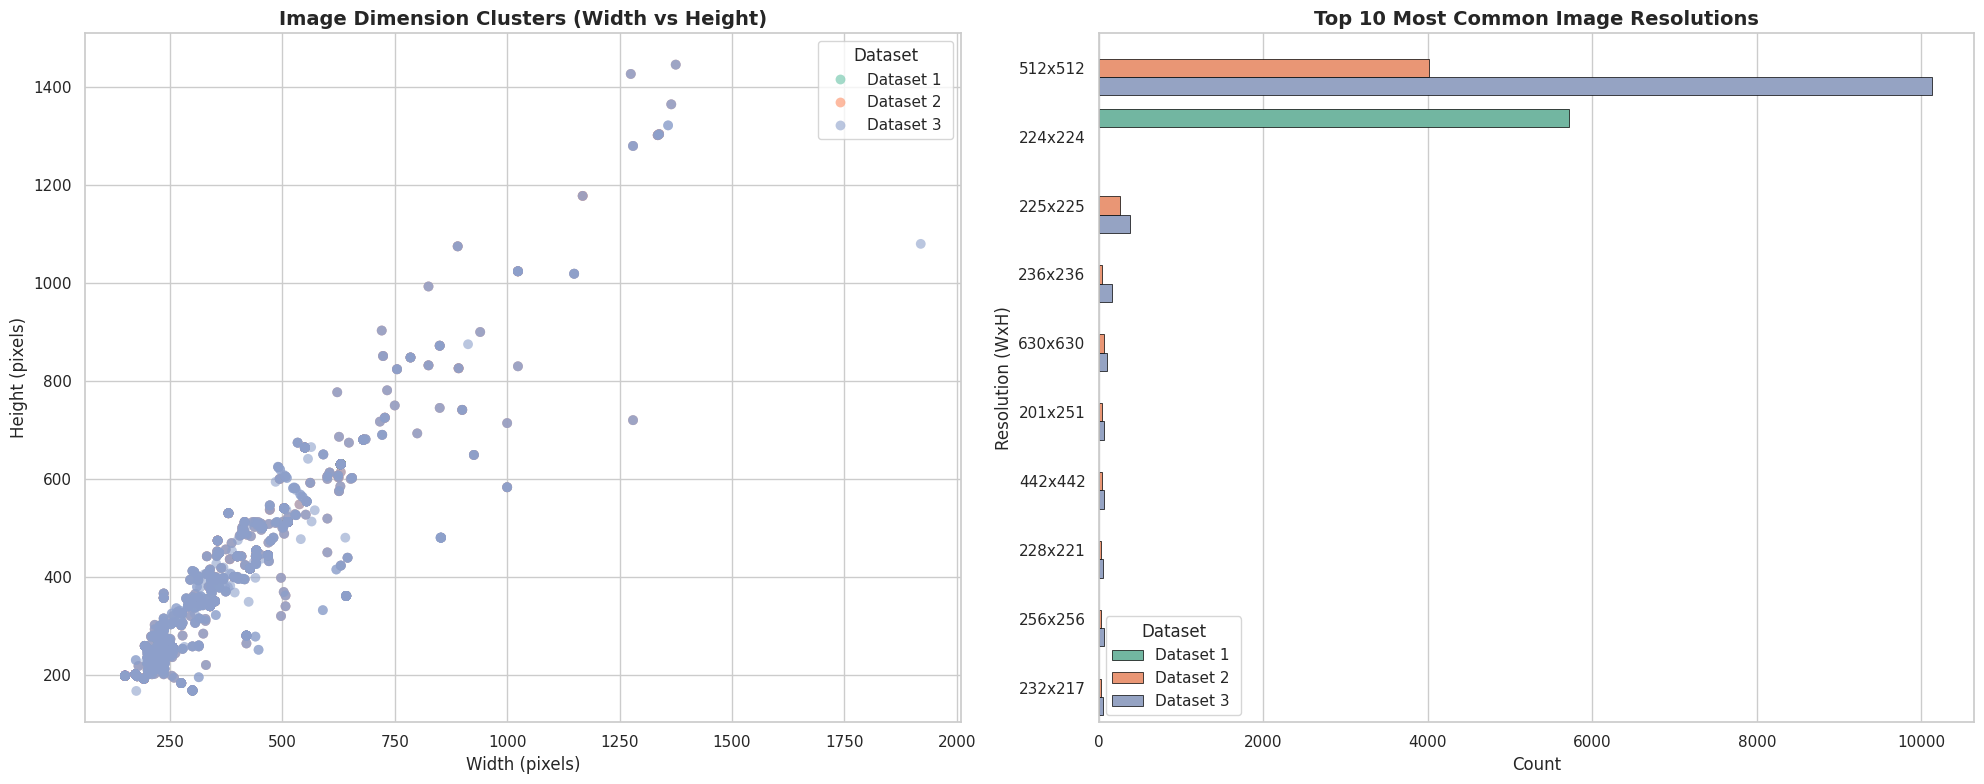

In [9]:
resolution_records = []

print("Scanning image resolutions (this might take a minute)...")


for name, base_path in zip(dataset_names, dataset_paths):
    if not os.path.exists(base_path):
        print(f"Skipping {name}: Path not found.")
        continue
        
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, file)
                
                
                img = cv2.imread(img_path)
                if img is not None:
                    h, w, _ = img.shape
                    resolution_records.append({
                        "Dataset": name,
                        "Width": w,
                        "Height": h,
                        "Resolution": f"{w}x{h}"
                    })

df_res = pd.DataFrame(resolution_records)
print(f"Scan complete! Analyzed {len(df_res)} total images.")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="whitegrid")


sns.scatterplot(
    data=df_res, 
    x="Width", 
    y="Height", 
    hue="Dataset", 
    alpha=0.6, 
    palette="Set2", 
    ax=ax1,
    s=50,
    edgecolor='none'
)
ax1.set_title("Image Dimension Clusters (Width vs Height)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Width (pixels)", fontsize=12)
ax1.set_ylabel("Height (pixels)", fontsize=12)


top_resolutions = df_res['Resolution'].value_counts().nlargest(10).index
df_top_res = df_res[df_res['Resolution'].isin(top_resolutions)]

sns.countplot(
    data=df_top_res, 
    y="Resolution", 
    hue="Dataset", 
    palette="Set2", 
    ax=ax2,
    order=top_resolutions,
    edgecolor='black',
    linewidth=0.5
)
ax2.set_title("Top 10 Most Common Image Resolutions", fontsize=14, fontweight='bold')
ax2.set_xlabel("Count", fontsize=12)
ax2.set_ylabel("Resolution (WxH)", fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
ds1_path = "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset"
ds2_path = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
ds3_path = "/kaggle/input/datasets/sabersakin/brainmri"


In [11]:
import os
from pathlib import Path
import pandas as pd


datasets_dict = {
    "Dataset 1 (7023 Images)": "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset",
    "Dataset 2 (Masoud)": "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    "Dataset 3 (Saber)": "/kaggle/input/datasets/sabersakin/brainmri"
}


target_classes = ["glioma", "meningioma", "pituitary", "notumor"]


report_data = []


for ds_name, ds_path in datasets_dict.items():
    if not os.path.exists(ds_path):
        print(f"পাথ পাওয়া যায়নি: {ds_name}")
        continue
    
    
    class_counts = {cls: 0 for cls in target_classes}
    
    
    for root, dirs, files in os.walk(ds_path):
        folder_name = os.path.basename(root).lower().replace(" ", "").replace("_", "")
        
      
        matched_class = None
        for cls in target_classes:
            if cls in folder_name or (cls == "notumor" and "no" in folder_name and "tumor" in folder_name):
                matched_class = cls
                break
                
        if matched_class:
            
            img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[matched_class] += len(img_files)
            
   
    for cls, count in class_counts.items():
        report_data.append({
            "Dataset Name": ds_name,
            "Brain Tumor Class": cls.upper(),
            "Total Images (Train + Test)": count
        })
df = pd.DataFrame(report_data)
pivot_df = df.pivot(index="Dataset Name", columns="Brain Tumor Class", values="Total Images (Train + Test)")
print("--- ডাটাসেট এবং ক্লাস অনুযায়ী ইমেজের সংখ্যা ---")
display(pivot_df)

--- ডাটাসেট এবং ক্লাস অনুযায়ী ইমেজের সংখ্যা ---


Brain Tumor Class,GLIOMA,MENINGIOMA,NOTUMOR,PITUITARY
Dataset Name,,,,
Dataset 1 (7023 Images),1621,1645,2000,1757
Dataset 2 (Masoud),1800,1800,1800,1800
Dataset 3 (Saber),3973,3290,2500,3588


In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import ConcatDataset


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

loaded_datasets = []


for ds_name, ds_path in datasets_dict.items():
    if not os.path.exists(ds_path):
        continue
        
   
    for sub_folder in os.listdir(ds_path):
        sub_folder_path = os.path.join(ds_path, sub_folder)
        
        if os.path.isdir(sub_folder_path):
            try:
               
                data = datasets.ImageFolder(root=sub_folder_path, transform=transform)
                loaded_datasets.append(data)
                print(f"Loaded successfully: {ds_name} -> {sub_folder} | Classes found: {data.classes}")
            except Exception as e:
               
                pass

final_combined_dataset = ConcatDataset(loaded_datasets)
print(f"\nসর্বমোট ৩টি ডাটাসেট মিলে ইমেজের সংখ্যা: {len(final_combined_dataset)}")

Loaded successfully: Dataset 1 (7023 Images) -> Training | Classes found: ['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']
Loaded successfully: Dataset 1 (7023 Images) -> Testing | Classes found: ['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']
Loaded successfully: Dataset 2 (Masoud) -> Training | Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Loaded successfully: Dataset 2 (Masoud) -> Testing | Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
Loaded successfully: Dataset 3 (Saber) -> Datasest Merged 1 | Classes found: ['Datasest Merged 1']
Loaded successfully: Dataset 3 (Saber) -> test | Classes found: ['test']

সর্বমোট ৩টি ডাটাসেট মিলে ইমেজের সংখ্যা: 27578


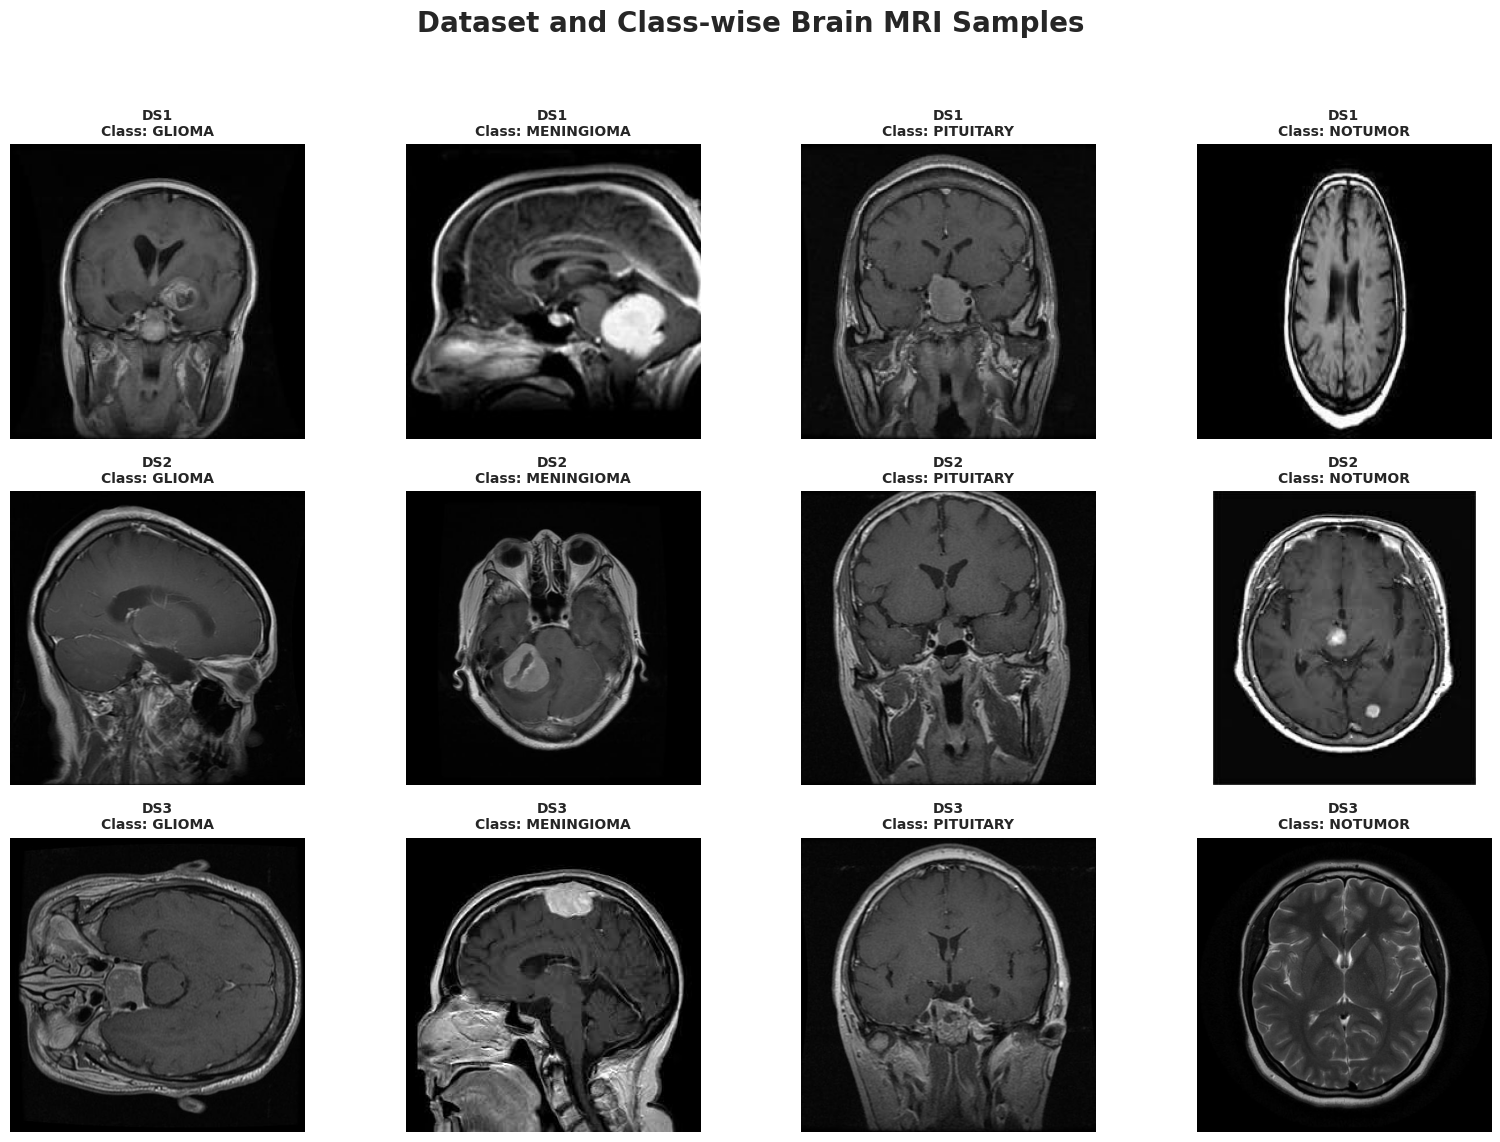

In [13]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image


datasets_dict = {
    "DS1": "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset",
    "DS2": "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    "DS3": "/kaggle/input/datasets/sabersakin/brainmri"
}


target_classes = ["glioma", "meningioma", "pituitary", "notumor"]


fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Dataset and Class-wise Brain MRI Samples", fontsize=20, weight='bold', y=0.95)


for row_idx, (ds_name, ds_path) in enumerate(datasets_dict.items()):
    if not os.path.exists(ds_path):
        print(f"পাথ পাওয়া যায়নি: {ds_name}")
        continue
        
    for col_idx, target_cls in enumerate(target_classes):
        all_images_for_class = []
        
        for root, dirs, files in os.walk(ds_path):
            folder_name = os.path.basename(root).lower().replace(" ", "").replace("_", "")
            is_match = False
            if target_cls in folder_name:
                is_match = True
            elif target_cls == "notumor" and ("no" in folder_name and "tumor" in folder_name):
                is_match = True
                
            if is_match:
                for file in files:
                    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        all_images_for_class.append(os.path.join(root, file))
                        
        
        ax = axes[row_idx, col_idx]
        if all_images_for_class:
            random_img_path = random.choice(all_images_for_class)
            img = Image.open(random_img_path).convert('RGB')
            
            
            ax.imshow(img)
            ax.set_title(f"{ds_name}\nClass: {target_cls.upper()}", fontsize=10, weight='semibold')
        else:
          
            ax.text(0.5, 0.5, 'No Image Found\n(Check Class Name)', ha='center', va='center', color='red')
            ax.set_title(f"{ds_name}\nClass: {target_cls.upper()}", fontsize=10)
            
        ax.axis('off') 

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

--- Class Distribution Table ---


Class,GLIOMA,MENINGIOMA,NOTUMOR,PITUITARY
Dataset,,,,
DS1 (7023 Images),1621,1645,2000,1757
DS2 (Masoud),1800,1800,1800,1800
DS3 (Saber),3973,3290,2500,3588


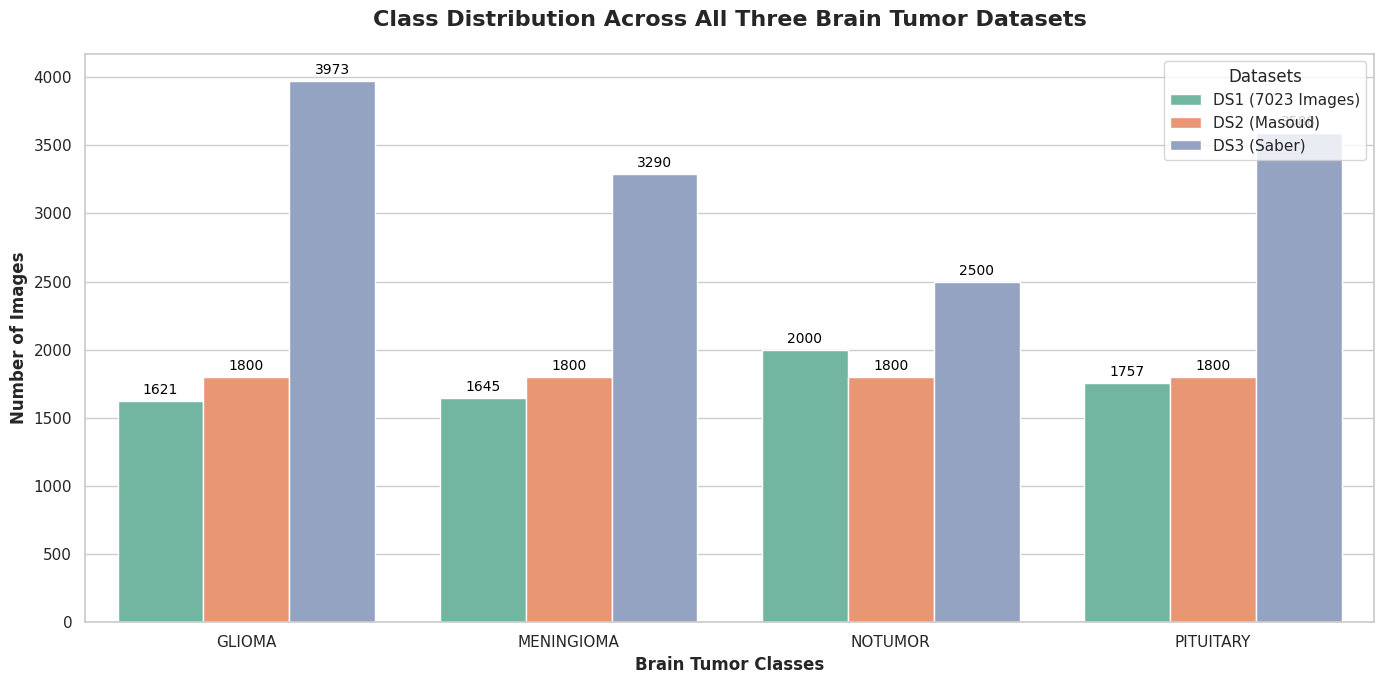

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


datasets_dict = {
    "DS1 (7023 Images)": "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset",
    "DS2 (Masoud)": "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    "DS3 (Saber)": "/kaggle/input/datasets/sabersakin/brainmri"
}


target_classes = ["glioma", "meningioma", "pituitary", "notumor"]


distribution_data = []


for ds_name, ds_path in datasets_dict.items():
    if not os.path.exists(ds_path):
        continue
        
    for root, dirs, files in os.walk(ds_path):
        folder_name = os.path.basename(root).lower().replace(" ", "").replace("_", "")
        
       
        matched_class = None
        for cls in target_classes:
            if cls in folder_name or (cls == "notumor" and "no" in folder_name and "tumor" in folder_name):
                matched_class = cls
                break
                
        if matched_class:
            img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
           
            split_type = "Unknown"
            if "train" in root.lower():
                split_type = "Train"
            elif "test" in root.lower() or "val" in root.lower():
                split_type = "Test"
                
            distribution_data.append({
                "Dataset": ds_name,
                "Class": matched_class.upper(),
                "Split": split_type,
                "Count": len(img_files)
            })


df = pd.DataFrame(distribution_data)


df_grouped = df.groupby(["Dataset", "Class"])["Count"].sum().reset_index()


print("--- Class Distribution Table ---")
pivot_df = df_grouped.pivot(index="Dataset", columns="Class", values="Count").fillna(0).astype(int)
display(pivot_df)

print("\n" + "="*50 + "\n")


plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")


ax = sns.barplot(x="Class", y="Count", hue="Dataset", data=df_grouped, palette="Set2")


for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='baseline', 
                    fontsize=10, color='black', 
                    xytext=(0, 5), 
                    textcoords='offset points')

plt.title("Class Distribution Across All Three Brain Tumor Datasets", fontsize=16, weight='bold', pad=20)
plt.xlabel("Brain Tumor Classes", fontsize=12, weight='semibold')
plt.ylabel("Number of Images", fontsize=12, weight='semibold')
plt.legend(title="Datasets", loc="upper right")
plt.tight_layout()
plt.show()

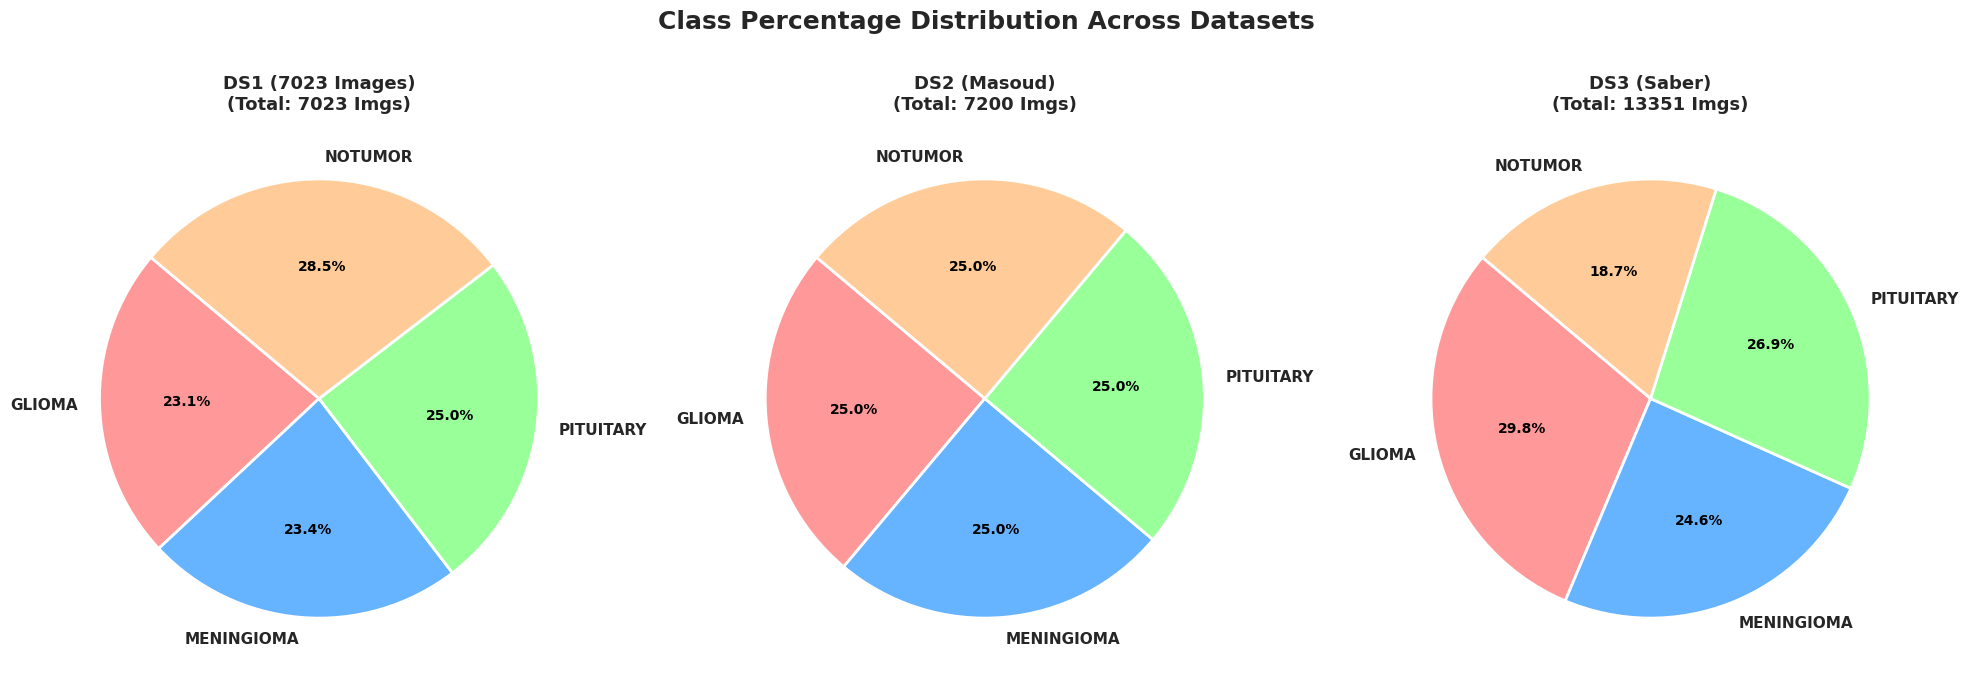

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt


datasets_dict = {
    "DS1 (7023 Images)": "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset",
    "DS2 (Masoud)": "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    "DS3 (Saber)": "/kaggle/input/datasets/sabersakin/brainmri"
}


target_classes = ["glioma", "meningioma", "pituitary", "notumor"]


ds_charts_data = {}


for ds_name, ds_path in datasets_dict.items():
    if not os.path.exists(ds_path):
        continue
        
    class_counts = {cls.upper(): 0 for cls in target_classes}
    
    for root, dirs, files in os.walk(ds_path):
        folder_name = os.path.basename(root).lower().replace(" ", "").replace("_", "")
        
        matched_class = None
        for cls in target_classes:
            if cls in folder_name or (cls == "notumor" and "no" in folder_name and "tumor" in folder_name):
                matched_class = cls.upper()
                break
                
        if matched_class:
            img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[matched_class] += len(img_files)
            
    ds_charts_data[ds_name] = class_counts



fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Class Percentage Distribution Across Datasets", fontsize=18, weight='bold', y=1.02)


colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']


for idx, (ds_name, counts_dict) in enumerate(ds_charts_data.items()):
    ax = axes[idx]
    
   
    labels = [cls for cls, count in counts_dict.items() if count > 0]
    sizes = [count for cls, count in counts_dict.items() if count > 0]
    
    
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors[:len(sizes)],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True}
    )
    
   
    for text in texts:
        text.set_fontsize(11)
        text.set_weight('semibold')
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_color('black')
        autotext.set_weight('bold')
        
    ax.set_title(f"{ds_name}\n(Total: {sum(sizes)} Imgs)", fontsize=13, weight='bold', pad=10)

plt.tight_layout()
plt.show()

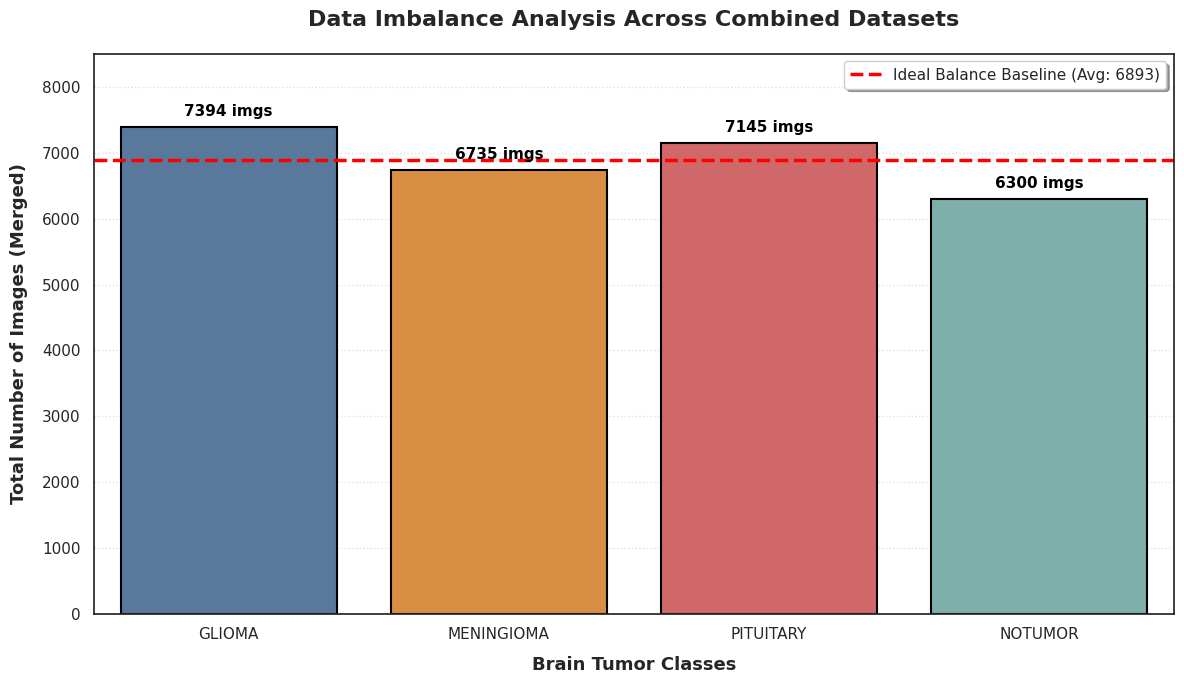

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


datasets_dict = {
    "DS1 (7023 Images)": "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset",
    "DS2 (Masoud)": "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    "DS3 (Saber)": "/kaggle/input/datasets/sabersakin/brainmri"
}


target_classes = ["glioma", "meningioma", "pituitary", "notumor"]


total_class_counts = {cls.upper(): 0 for cls in target_classes}


for ds_name, ds_path in datasets_dict.items():
    if not os.path.exists(ds_path):
        continue
        
    for root, dirs, files in os.walk(ds_path):
        folder_name = os.path.basename(root).lower().replace(" ", "").replace("_", "")
        
        matched_class = None
        for cls in target_classes:
            if cls in folder_name or (cls == "notumor" and "no" in folder_name and "tumor" in folder_name):
                matched_class = cls.upper()
                break
                
        if matched_class:
            img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            total_class_counts[matched_class] += len(img_files)


df_imbalance = pd.DataFrame(list(total_class_counts.items()), columns=["Class", "Total_Images"])


ideal_average = df_imbalance["Total_Images"].mean()


plt.figure(figsize=(12, 7))
sns.set_theme(style="white")


colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

ax = sns.barplot(x="Class", y="Total_Images", data=df_imbalance, palette=colors, edgecolor="black", linewidth=1.5)


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} imgs', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=11, color='black', weight='bold',
                xytext=(0, 8), 
                textcoords='offset points')


plt.axhline(ideal_average, color='red', linestyle='--', linewidth=2.5, 
            label=f'Ideal Balance Baseline (Avg: {int(ideal_average)})')


plt.title("Data Imbalance Analysis Across Combined Datasets", fontsize=16, weight='bold', pad=20)
plt.xlabel("Brain Tumor Classes", fontsize=13, weight='semibold', labelpad=10)
plt.ylabel("Total Number of Images (Merged)", fontsize=13, weight='semibold', labelpad=10)
plt.ylim(0, df_imbalance["Total_Images"].max() * 1.15) 
plt.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Scanning images for resolutions... Please wait.


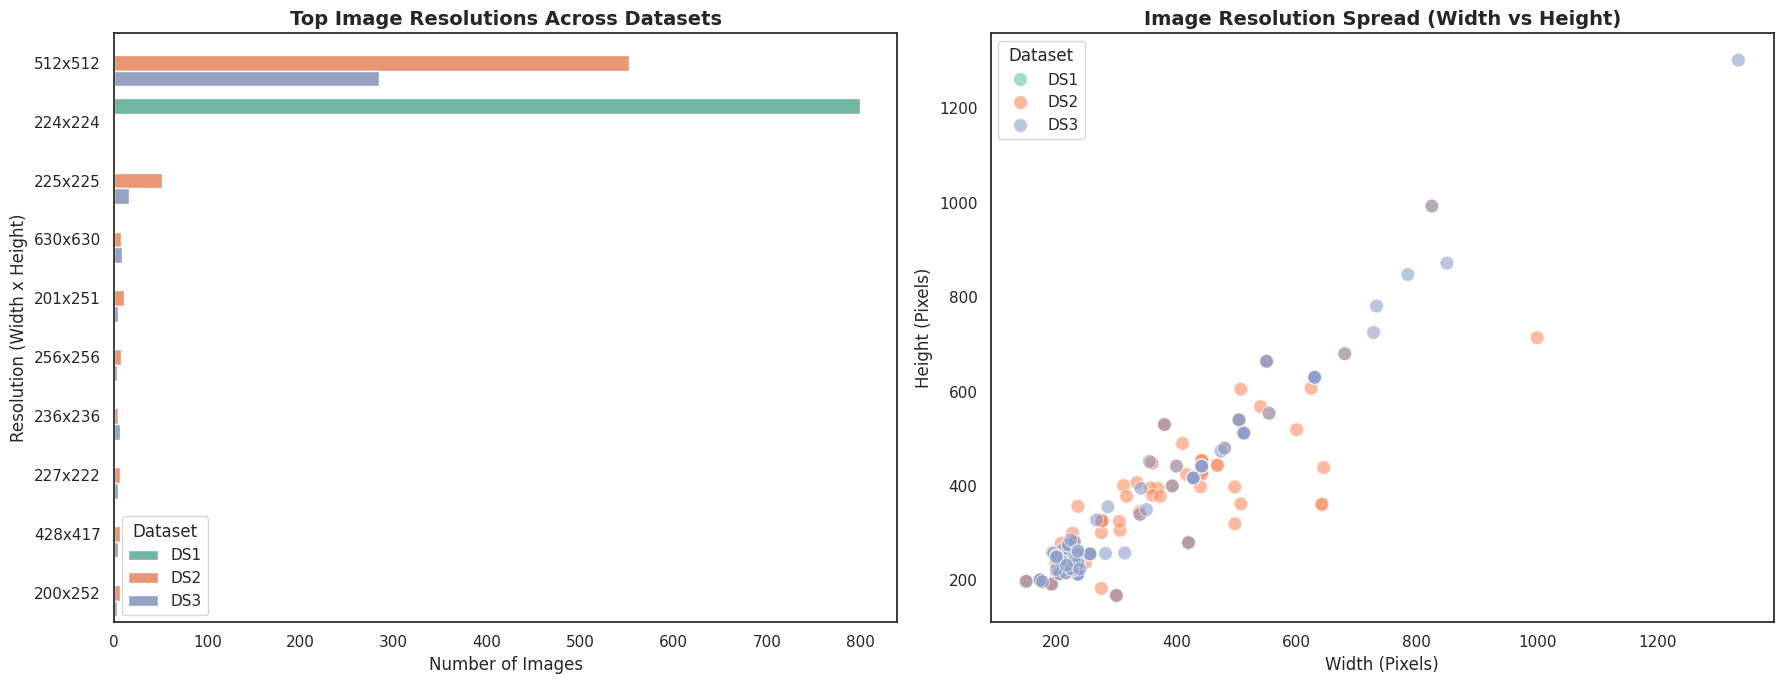


--- Resolution Summary Table ---


,Dataset,Resolution,Count
0,DS1,224x224,800
82,DS2,512x512,552
30,DS2,225x225,51
9,DS2,201x251,11
88,DS2,630x630,8
...,...,...,...
157,DS3,728x725,1
158,DS3,733x781,1
159,DS3,785x848,1
160,DS3,825x993,1


In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


datasets_dict = {
    "DS1": "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset",
    "DS2": "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    "DS3": "/kaggle/input/datasets/sabersakin/brainmri"
}


resolution_data = []

print("Scanning images for resolutions... Please wait.")


for ds_name, ds_path in datasets_dict.items():
    if not os.path.exists(ds_path):
        continue
        
    for root, dirs, files in os.walk(ds_path):
       
        img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
       
        for file in img_files[:100]: 
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    resolution_data.append({
                        "Dataset": ds_name,
                        "Width": width,
                        "Height": height,
                        "Resolution": f"{width}x{height}"
                    })
            except:
               
                continue


df_res = pd.DataFrame(resolution_data)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")


top_res = df_res["Resolution"].value_counts().index[:10] 
df_top_res = df_res[df_res["Resolution"].isin(top_res)]

sns.countplot(
    y="Resolution", 
    hue="Dataset", 
    data=df_top_res, 
    ax=axes[0], 
    palette="Set2",
    order=top_res
)
axes[0].set_title("Top Image Resolutions Across Datasets", fontsize=14, weight='bold')
axes[0].set_xlabel("Number of Images")
axes[0].set_ylabel("Resolution (Width x Height)")


sns.scatterplot(
    x="Width", 
    y="Height", 
    hue="Dataset", 
    data=df_res, 
    alpha=0.6, 
    s=100, 
    ax=axes[1],
    palette="Set2"
)
axes[1].set_title("Image Resolution Spread (Width vs Height)", fontsize=14, weight='bold')
axes[1].set_xlabel("Width (Pixels)")
axes[1].set_ylabel("Height (Pixels)")

plt.tight_layout()
plt.show()


print("\n--- Resolution Summary Table ---")
summary_df = df_res.groupby(["Dataset", "Resolution"]).size().reset_index(name="Count")
display(summary_df.sort_values(by=["Dataset", "Count"], ascending=[True, False]))